In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

*BEFORE JOINING DATA*

In [2]:
sites = pd.read_csv('Data/Solar_Site_Details.csv')
summary = pd.read_csv('Data/Monthly_Summary_Solar.csv')

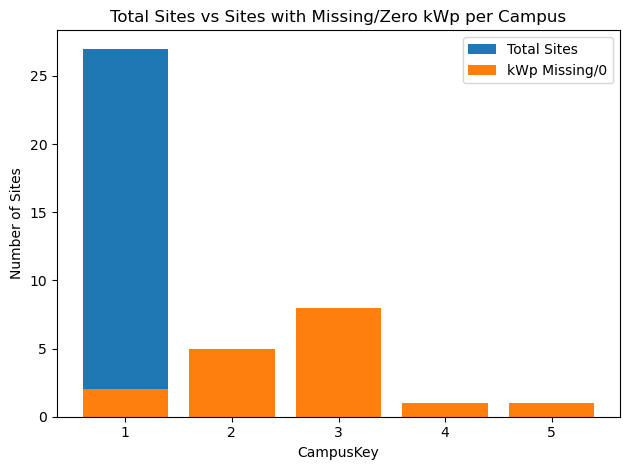

In [3]:
invalid_kwp = sites["kWp"].isna() | (sites["kWp"] == 0)

campus_stats = sites.groupby("CampusKey").agg(
    total_sites=("SiteKey", "nunique"),
    invalid_kwp_sites=("SiteKey", lambda x: x[invalid_kwp.loc[x.index]].nunique())
)
plt.figure()

plt.bar(campus_stats.index, campus_stats["total_sites"], label="Total Sites")
plt.bar(campus_stats.index, campus_stats["invalid_kwp_sites"], label="kWp Missing/0")
plt.title("Total Sites vs Sites with Missing/Zero kWp per Campus")
plt.xlabel("CampusKey")
plt.ylabel("Number of Sites")
plt.legend()
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Solar Capacity (kWp) for Campus 1')

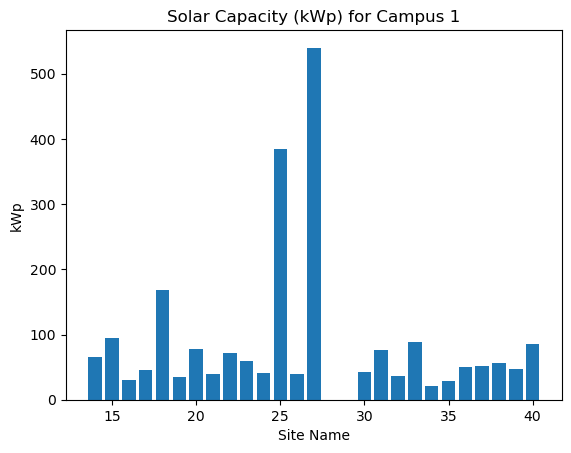

In [4]:
subset = sites[sites["CampusKey"] == 1]

plt.bar(subset["SiteKey"], subset["kWp"])
plt.xlabel("Site Name")
plt.ylabel("kWp")
plt.title("Solar Capacity (kWp) for Campus 1")

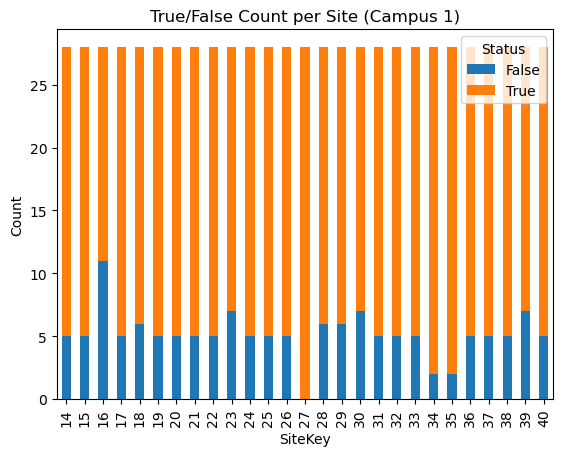

In [5]:
summary = summary.merge(
    sites[["SiteKey", "CampusKey"]].drop_duplicates(),
    on="SiteKey",
    how="left"
)
summary_c1 = summary[summary["CampusKey"] == 1]
status_counts = summary_c1.groupby("SiteKey")["DataStatus"].value_counts().unstack(fill_value=0)
status_counts.plot(kind="bar", stacked=True)

plt.title("True/False Count per Site (Campus 1)")
plt.xlabel("SiteKey")
plt.ylabel("Count")
plt.legend(title="Status")
plt.show()

*AFTER JOINING DATA*

In [6]:
data = pd.read_csv('Data/Joined_Data.csv', low_memory=False)

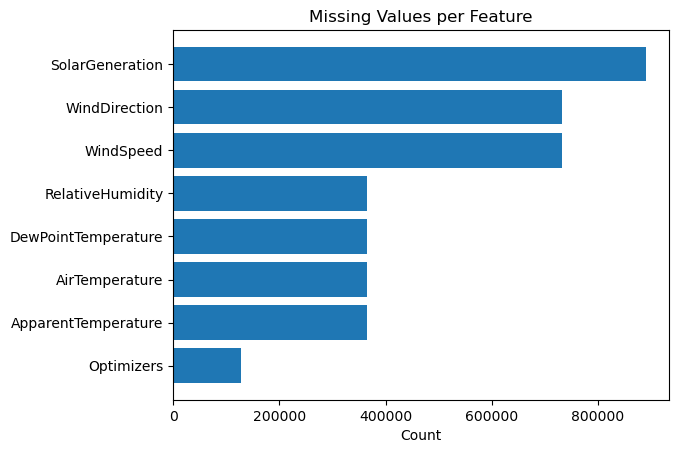

In [7]:
missing = data.isna().sum()
missing = missing[missing > 0].sort_values()

plt.figure()
plt.barh(missing.index, missing.values)
plt.title("Missing Values per Feature")
plt.xlabel("Count")
plt.show()

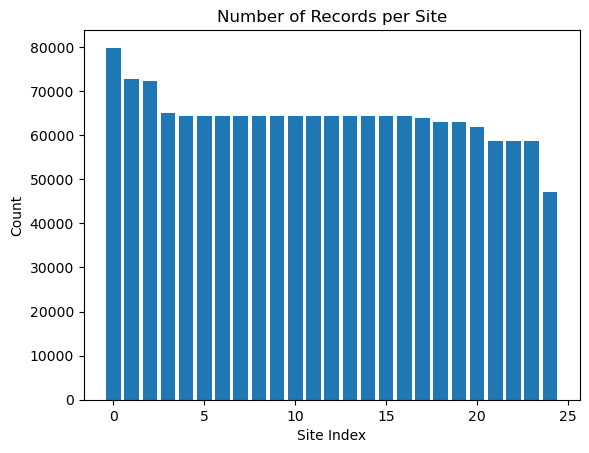

In [8]:
site_counts = data["SiteKey"].value_counts()

plt.figure()
plt.bar(range(len(site_counts)), site_counts.values)
plt.title("Number of Records per Site")
plt.xlabel("Site Index")
plt.ylabel("Count")
plt.show()

*AFTER FEATURE ENGINEERING*

In [9]:
data1 = pd.read_csv('Data/Final_Data.csv')

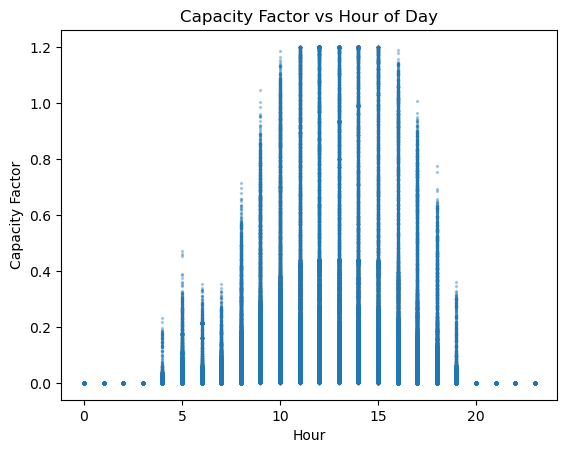

In [10]:
data1["hour_reconstructed"] = (
    np.arctan2(data1["Hour_sin"], data1["Hour_cos"]) * 24 / (2 * np.pi)
) % 24

plt.figure()
plt.scatter(data1["hour_reconstructed"], data1["CapacityFactor"], s=2, alpha=0.3)
plt.title("Capacity Factor vs Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Capacity Factor")
plt.show()

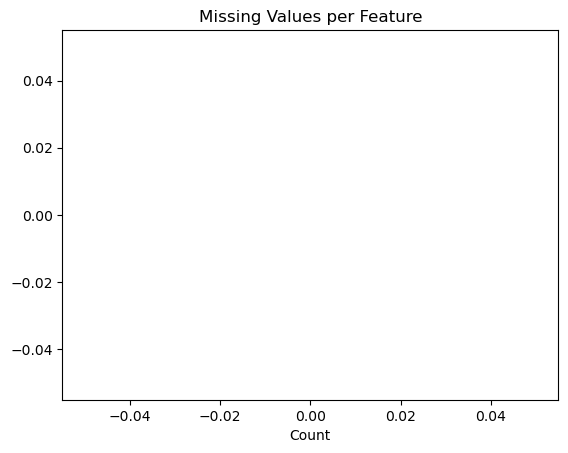

In [11]:
missing = data1.isna().sum()
missing = missing[missing > 0].sort_values()

plt.figure()
plt.barh(missing.index, missing.values)
plt.title("Missing Values per Feature")
plt.xlabel("Count")
plt.show()

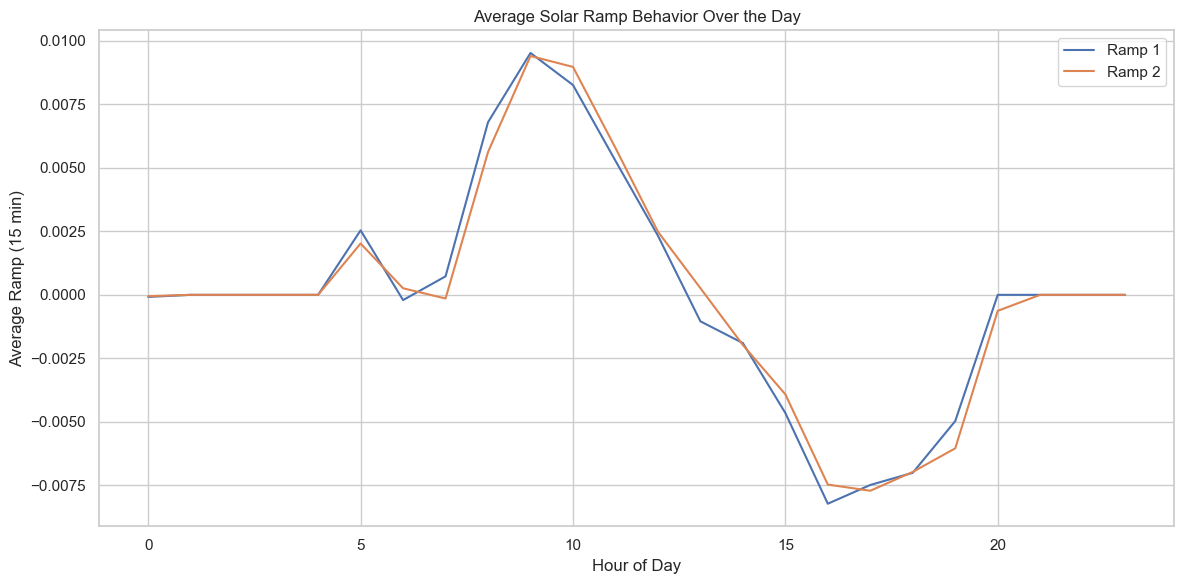

In [22]:
sns.set(style="whitegrid")
agg = data1.groupby("hour_reconstructed")[["Ramp_1","Ramp_2"]].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=agg, x='hour_reconstructed', y='Ramp_1', label='Ramp 1')
sns.lineplot(data=agg, x='hour_reconstructed', y='Ramp_2', label='Ramp 2')
plt.xlabel('Hour of Day')
plt.ylabel('Average Ramp (15 min)')
plt.title('Average Solar Ramp Behavior Over the Day')
plt.tight_layout()
plt.show()

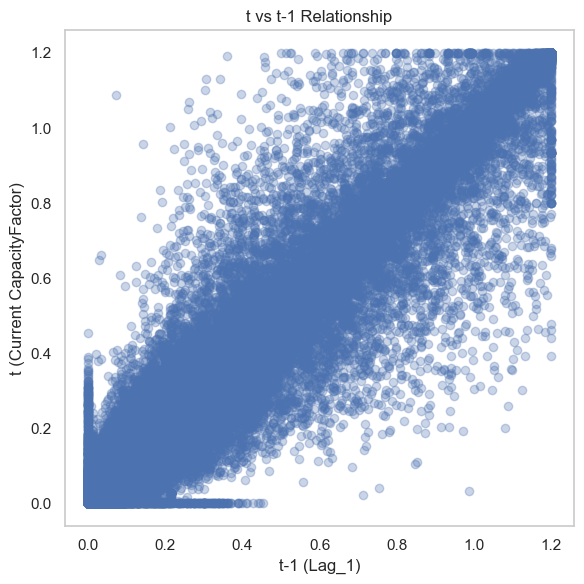

In [13]:
plt.figure(figsize=(6,6))
plt.scatter(data1["Lag_1"], data1["CapacityFactor"], alpha=0.3)
plt.xlabel("t-1 (Lag_1)")
plt.ylabel("t (Current CapacityFactor)")
plt.title("t vs t-1 Relationship")
plt.plot([0,1],[0,1], linestyle='--')
plt.grid()
plt.tight_layout()
plt.show()

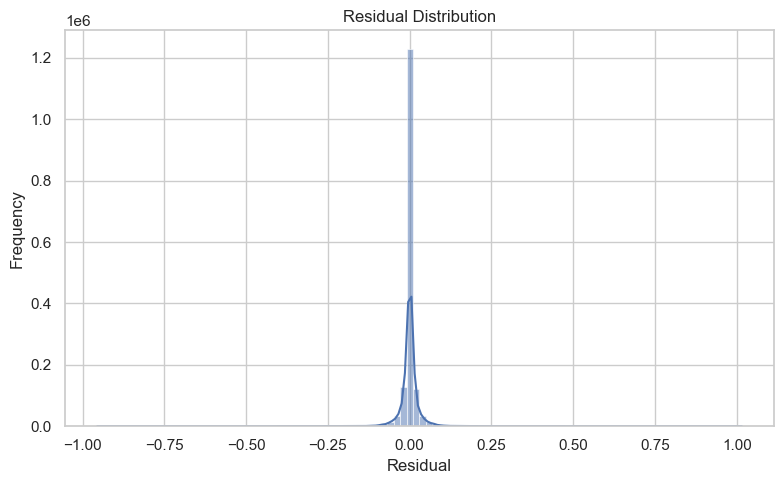

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(data1["Residual_now"], bins=100, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

*RESULTS*

In [15]:
res = pd.read_csv('Data/results.csv')

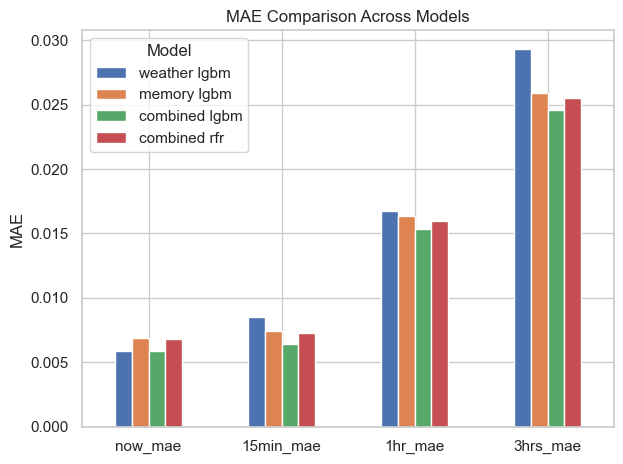

In [16]:
models = ["weather lgbm", "memory lgbm", "combined lgbm", "combined rfr"]
mae_cols = ["now_mae", "15min_mae", "1hr_mae", "3hrs_mae"]
df_mae = res[res["model"].isin(models)]
df_mae.set_index("model")[mae_cols].T.plot(kind="bar")

plt.title("MAE Comparison Across Models")
plt.ylabel("MAE")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

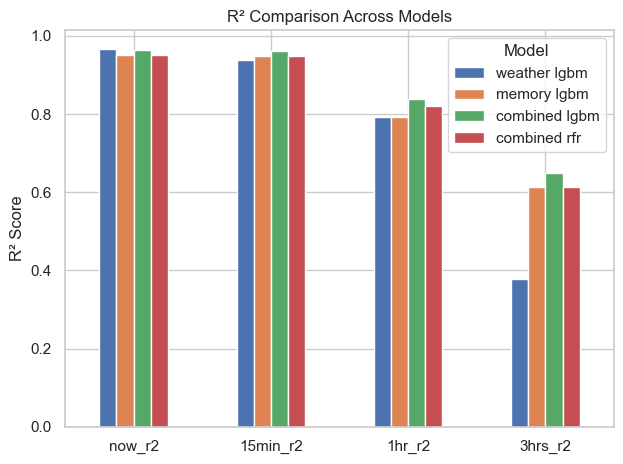

In [17]:
r2_cols = ["now_r2", "15min_r2", "1hr_r2", "3hrs_r2"]
df_r2 = res[res["model"].isin(models)]
df_r2.set_index("model")[r2_cols].T.plot(kind="bar")

plt.title("R² Comparison Across Models")
plt.ylabel("R² Score")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

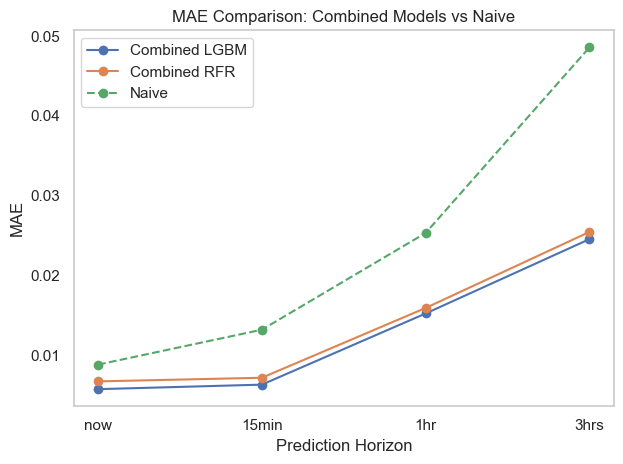

In [18]:
horizons = ["now", "15min", "1hr", "3hrs"]
x = np.arange(len(horizons))
lgbm_row = res[res["model"] == "combined lgbm"]
rfr_row = res[res["model"] == "combined rfr"]
plt.plot(
    x,
    [lgbm_row[f"{h}_mae"].values[0] for h in horizons],
    marker='o',
    label="Combined LGBM"
)
plt.plot(
    x,
    [rfr_row[f"{h}_mae"].values[0] for h in horizons],
    marker='o',
    label="Combined RFR"
)
plt.plot(
    x,
    [lgbm_row[f"{h}_naive"].values[0] for h in horizons],
    marker='o',
    linestyle='--',
    label="Naive"
)

plt.xticks(x, horizons)
plt.title("MAE Comparison: Combined Models vs Naive")
plt.ylabel("MAE")
plt.xlabel("Prediction Horizon")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

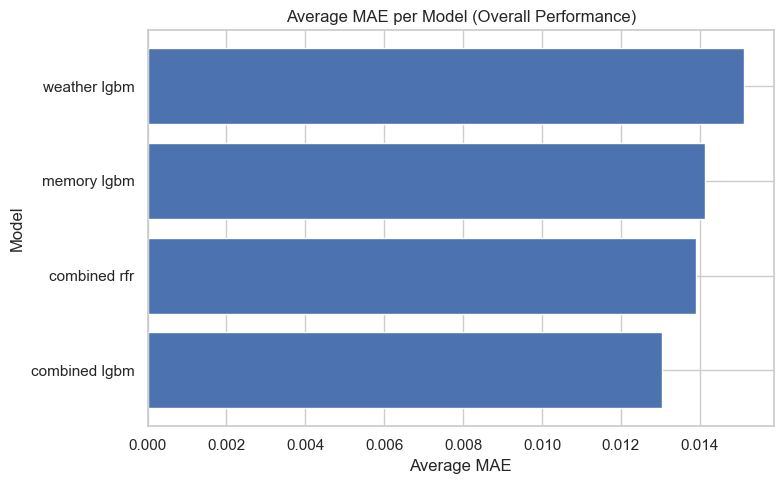

In [19]:
res["avg_mae"] = res[["now_mae","15min_mae","1hr_mae","3hrs_mae"]].mean(axis=1)
sorted_res = res.sort_values("avg_mae")

plt.figure(figsize=(8,5))
plt.barh(sorted_res["model"], sorted_res["avg_mae"])
plt.title("Average MAE per Model (Overall Performance)")
plt.xlabel("Average MAE")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

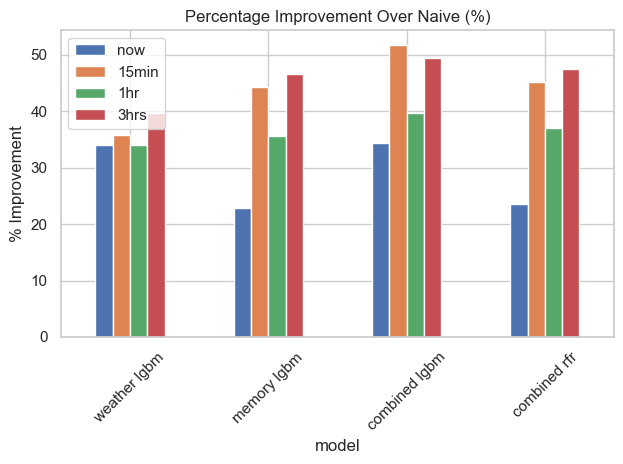

In [20]:
improvement = pd.DataFrame()
improvement["model"] = res["model"]
for h in ["now","15min","1hr","3hrs"]:
    improvement[h] = 100 * (res[f"{h}_naive"] - res[f"{h}_mae"]) / res[f"{h}_naive"]
improvement.set_index("model").plot(kind="bar")

plt.title("Percentage Improvement Over Naive (%)")
plt.ylabel("% Improvement")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

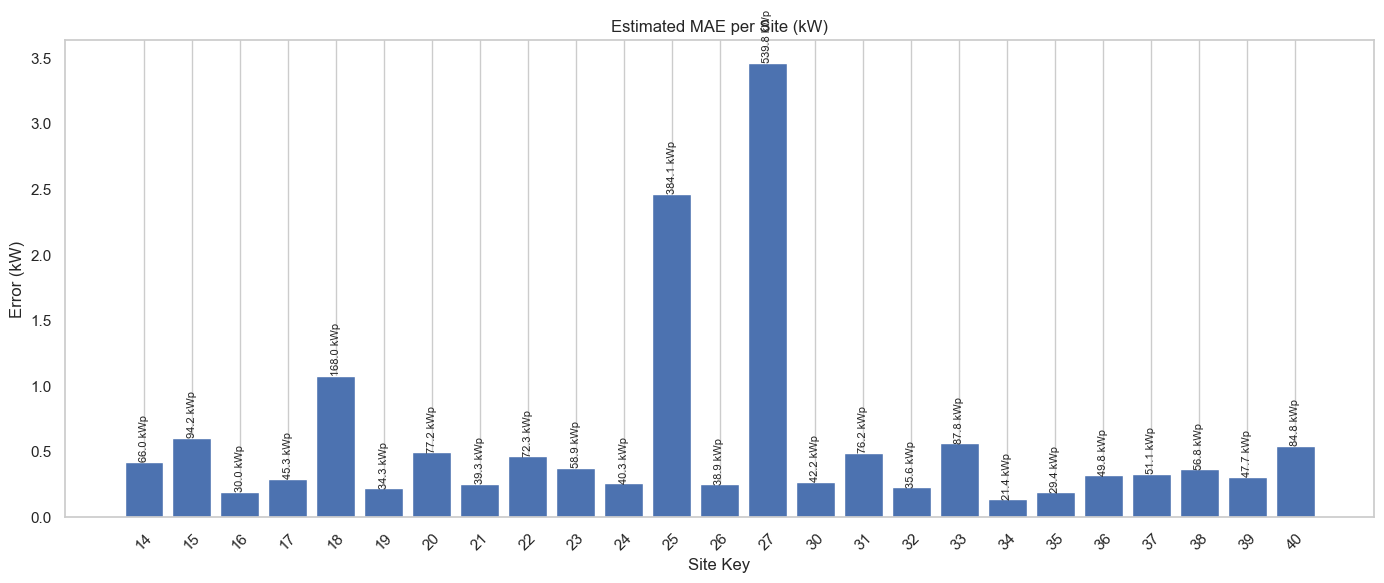

In [21]:
site_capacity = sites[sites["CampusKey"]==1]
site_capacity = site_capacity[~site_capacity['SiteKey'].isin([28,29])]
mae_cf = 0.006416115620519883
values = site_capacity["kWp"] * mae_cf
site_keys = site_capacity["SiteKey"].astype(str)
kwp_values = site_capacity["kWp"].values

plt.figure(figsize=(14,6))
bars = plt.bar(site_keys, values)
plt.title("Estimated MAE per Site (kW)")
plt.ylabel("Error (kW)")
plt.xlabel("Site Key")
plt.xticks(rotation=45)
plt.grid(axis='y')

for bar, kwp in zip(bars, kwp_values):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{kwp:.1f} kWp",
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=90
    )
plt.tight_layout()
plt.show()